In [ ]:
!nvidia-smi


Sun Feb 15 03:29:33 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8              9W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
!pip install -q transformers accelerate bitsandbytes sentence-transformers faiss-cpu scikit-learn


In [ ]:
import faiss
import json

index = faiss.read_index("vector_store.index")

with open("metadata.json", "r", encoding="utf-8") as f:
    metadata = json.load(f)

print("Vectors loaded:", len(metadata))



Vectors loaded: 112


In [ ]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("intfloat/e5-base-v2")


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


modules.json:   0%|          | 0.00/387 [00:00<?, ?B/s]

README.md: 0.00B [00:00, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/57.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/650 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/314 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

special_tokens_map.json:   0%|          | 0.00/125 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/200 [00:00<?, ?B/s]

In [ ]:
import torch
from transformers import AutoTokenizer, AutoModelForCausalLM, BitsAndBytesConfig

model_name = "mistralai/Mistral-7B-Instruct-v0.2"

bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_compute_dtype=torch.float16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(model_name)

model = AutoModelForCausalLM.from_pretrained(
    model_name,
    quantization_config=bnb_config,
    device_map="auto"
)

print("Mistral loaded successfully.")


config.json:   0%|          | 0.00/596 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 3 files:   0%|          | 0/3 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/111 [00:00<?, ?B/s]

Mistral loaded successfully.


Cheking setup

In [ ]:
def generate_answer(query, context_chunks):

    MAX_CONTEXT_CHARS = 3000

    context = "\n\n".join(context_chunks)

    if len(context) > MAX_CONTEXT_CHARS:
        context = context[:MAX_CONTEXT_CHARS]

    prompt = f"""<s>[INST] You are a regulatory compliance assistant.
Answer strictly using the provided context.
If answer is not found, say:
Information not found in provided documents.

Context:
{context}

Question:
{query} [/INST]"""

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    with torch.no_grad():
        outputs = model.generate(
            **inputs,
            max_new_tokens=150,
            temperature=0.2,
            use_cache=False
        )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    torch.cuda.empty_cache()

    return decoded.split("[/INST]")[-1].strip()


In [ ]:
test_query = "What is the objective of Lead Bank Scheme?"
chunks = metadata[:3]  # just test small context
print(generate_answer(test_query, [c["text"] for c in chunks]))


The following generation flags are not valid and may be ignored: ['temperature']. Set `TRANSFORMERS_VERBOSITY=info` for more details.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.


The Lead Bank Scheme is a mechanism for coordination between banks and development agencies to ensure the implementation of development programs, including the provision of credit to Scheduled Castes (SCs) and Scheduled Tribes (STs) at the district level. The objective is to promote employment and development schemes and ensure a larger flow of credit to these communities for self-employment. Banks are encouraged to establish closer liaison with District Industries Centers and give weightage to SCs/STs in the planning process. They should also review their lending procedures and policies to ensure timely and adequate production-oriented loans.


# BASELINE RAG

In [ ]:
def baseline_rag(query):

    chunks = semantic_retrieve(query, top_k=5)

    answer = generate_answer(query, chunks)

    claims = decompose_claims(answer)

    support_scores = [compute_support_score(c, chunks) for c in claims]

    return {
        "answer": answer,
        "support_scores": support_scores
    }


In [ ]:
def generate_answer(query, context_chunks):

    MAX_CONTEXT_CHARS = 3000 # Limit context characters to avoid OOM

    context = "\n\n".join(context_chunks)

    if len(context) > MAX_CONTEXT_CHARS:
        context = context[:MAX_CONTEXT_CHARS]

    prompt = f"""<s>[INST] You are a regulatory compliance assistant.
Answer strictly using the provided context.
If answer is not found, say:
Information not found in provided documents.

Context:
{context}

Question:
{query} [/INST]"""

    inputs = tokenizer(prompt, return_tensors="pt").to("cuda")

    outputs = model.generate(
        **inputs,
        max_new_tokens=150, # Reduced for memory efficiency
        temperature=0.2
    )

    decoded = tokenizer.decode(outputs[0], skip_special_tokens=True)

    torch.cuda.empty_cache() # Clear cache after generation

    # Remove prompt part
    return decoded.split("[/INST]")[-1].strip()

# TA-RAG Pipeline

In [ ]:
# retival
import numpy as np
from sklearn.metrics.pairwise import cosine_similarity

TOP_K_STAGE1 =5 #due to h/w constaints 3 from 8
TOP_K_STAGE2 = 3

def semantic_retrieve(query, top_k=TOP_K_STAGE1):
    query_embedding = embedding_model.encode([f"query: {query}"])
    D, I = index.search(np.array(query_embedding).astype("float32"), top_k)

    return [metadata[idx]["text"] for idx in I[0]]


def rerank(query, chunks, top_k=TOP_K_STAGE2):
    query_emb = embedding_model.encode([f"query: {query}"])
    chunk_embs = embedding_model.encode([f"passage: {c}" for c in chunks])

    sims = cosine_similarity(query_emb, chunk_embs)[0]
    ranked = sorted(zip(chunks, sims), key=lambda x: x[1], reverse=True)

    return [c[0] for c in ranked[:top_k]]


In [ ]:
# Simple Claim Decomposition (Stable)
def decompose_claims(answer):
    sentences = answer.split(".")
    return [s.strip() for s in sentences if len(s.strip()) > 5]


In [ ]:
#support scoring
def compute_support_score(claim, retrieved_chunks):

    claim_embedding = embedding_model.encode([f"query: {claim}"])
    chunk_embeddings = embedding_model.encode(
        [f"passage: {c}" for c in retrieved_chunks]
    )

    similarities = cosine_similarity(claim_embedding, chunk_embeddings)[0]

    supported = [sim for sim in similarities if sim > 0.60]

    S_i = len(supported) / len(retrieved_chunks)

    return S_i


In [ ]:
#  Confidence + Rejection
CONFIDENCE_THRESHOLD = 0.75
CRITICAL_CLAIM_THRESHOLD = 0.5
MIN_EVIDENCE_COVERAGE = 0.75


def compute_confidence(support_scores):
    if len(support_scores) == 0:
        return 0
    return sum(support_scores) / len(support_scores)


def apply_rejection_policy(confidence, support_scores, evidence_coverage):

    if confidence < CONFIDENCE_THRESHOLD:
        return True

    if any(s < CRITICAL_CLAIM_THRESHOLD for s in support_scores):
        return True

    if evidence_coverage < MIN_EVIDENCE_COVERAGE:
        return True

    return False


In [ ]:
def ta_rag(query):

    stage1 = semantic_retrieve(query)
    stage2 = rerank(query, stage1)

    answer = generate_answer(query, stage2)

    claims = decompose_claims(answer)

    support_scores = []
    coverage_counter = 0

    for claim in claims:
        S_i = compute_support_score(claim, stage2)
        support_scores.append(S_i)

        if S_i > 0:
            coverage_counter += 1

    confidence = compute_confidence(support_scores)
    evidence_coverage = coverage_counter / len(claims) if claims else 0

    reject = apply_rejection_policy(
        confidence,
        support_scores,
        evidence_coverage
    )

    final_output = (
        "Insufficient verified evidence available in current regulatory corpus."
        if reject else answer
    )

    return {
        "final_output": final_output,
        "confidence": confidence,
        "support_scores": support_scores,
        "rejected": reject
    }


In [ ]:
test_queries = [

    # -------- 15 In-Scope --------
    {"query": "What is the objective of the Lead Bank Scheme introduced by RBI?", "type": "in-scope"},
    {"query": "Who chairs the District Consultative Committee meetings?", "type": "in-scope"},
    {"query": "How frequently are BLBC meetings conducted?", "type": "in-scope"},
    {"query": "What is the minimum professional director requirement for UCBs?", "type": "in-scope"},
    {"query": "Which Act empowers RBI to regulate UCBs?", "type": "in-scope"},
    {"query": "What is the role of the Lead District Manager?", "type": "in-scope"},
    {"query": "Who chairs SLBC meetings?", "type": "in-scope"},
    {"query": "What is the purpose of Audit Committee of the Board?", "type": "in-scope"},
    {"query": "What are the eligibility restrictions for becoming a director of a UCB?", "type": "in-scope"},
    {"query": "What is RBI’s instruction regarding honorary titles at Board level?", "type": "in-scope"},
    {"query": "What is the purpose of District Level Review Committee?", "type": "in-scope"},
    {"query": "What is the frequency of SLBC meetings?", "type": "in-scope"},
    {"query": "What is the role of private sector banks in Lead Bank Scheme?", "type": "in-scope"},
    {"query": "What is the purpose of Financial Literacy Centres?", "type": "in-scope"},
    {"query": "What is the requirement regarding Board of Management in UCBs?", "type": "in-scope"},

    # -------- 5 Multi-Hop --------
    {"query": "How does the Lead Bank Scheme ensure coordination between banks and government agencies?", "type": "multi-hop"},
    {"query": "What responsibilities do Directors have regarding RBI inspection reports?", "type": "multi-hop"},
    {"query": "How are DCC and DLRC meetings structured differently?", "type": "multi-hop"},
    {"query": "How does SLBC improve financial inclusion?", "type": "multi-hop"},
    {"query": "What mechanisms exist to improve credit absorption capacity?", "type": "multi-hop"},

    # -------- 5 Ambiguous --------
    {"query": "What are the responsibilities of banks under RBI?", "type": "ambiguous"},
    {"query": "How does RBI monitor rural banking?", "type": "ambiguous"},
    {"query": "What are governance requirements for banks?", "type": "ambiguous"},
    {"query": "How does RBI ensure financial discipline?", "type": "ambiguous"},
    {"query": "What is the role of committees in banking supervision?", "type": "ambiguous"},

    # -------- 5 Out-of-Scope --------
    {"query": "What are RBI guidelines on cryptocurrency regulation?", "type": "out-of-scope"},
    {"query": "What is capital adequacy ratio under Basel III?", "type": "out-of-scope"},
    {"query": "What are RBI digital lending guidelines?", "type": "out-of-scope"},
    {"query": "What are penalties for KYC non-compliance?", "type": "out-of-scope"},
    {"query": "What is RBI monetary policy stance for 2025?", "type": "out-of-scope"},
]

 # EVALUATION

In [ ]:
def evaluate_system(system_fn, test_queries):

    total_claims = 0
    unsupported_claims = 0
    hallucinated_answers = 0

    type_stats = {}

    for item in test_queries:

        query = item["query"]
        q_type = item["type"]

        result = system_fn(query)

        scores = result["support_scores"]

        if len(scores) == 0:
            continue

        # Initialize category tracking
        if q_type not in type_stats:
            type_stats[q_type] = {
                "claims": 0,
                "unsupported": 0,
                "answers": 0,
                "hallucinated": 0,
                "rejected": 0
            }

        type_stats[q_type]["claims"] += len(scores)
        type_stats[q_type]["answers"] += 1

        unsupported = [s for s in scores if s == 0]

        type_stats[q_type]["unsupported"] += len(unsupported)

        if len(unsupported) > 0:
            type_stats[q_type]["hallucinated"] += 1
            hallucinated_answers += 1

        if "rejected" in result and result["rejected"]:
            type_stats[q_type]["rejected"] += 1

        total_claims += len(scores)
        unsupported_claims += len(unsupported)

    claim_hr = unsupported_claims / total_claims
    binary_hr = hallucinated_answers / len(test_queries)

    return claim_hr, binary_hr, type_stats


In [ ]:
torch.cuda.empty_cache()


In [ ]:
baseline_metrics = evaluate_system(baseline_rag, test_queries)
ta_metrics = evaluate_system(ta_rag, test_queries)

print("Results are Saved")


Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for open-end generation.
Setting `pad_token_id` to `eos_token_id`:2 for o

Baseline Claim HR: 0.0
Baseline Binary HR: 0.0
TA-RAG Claim HR: 0.0
TA-RAG Binary HR: 0.0


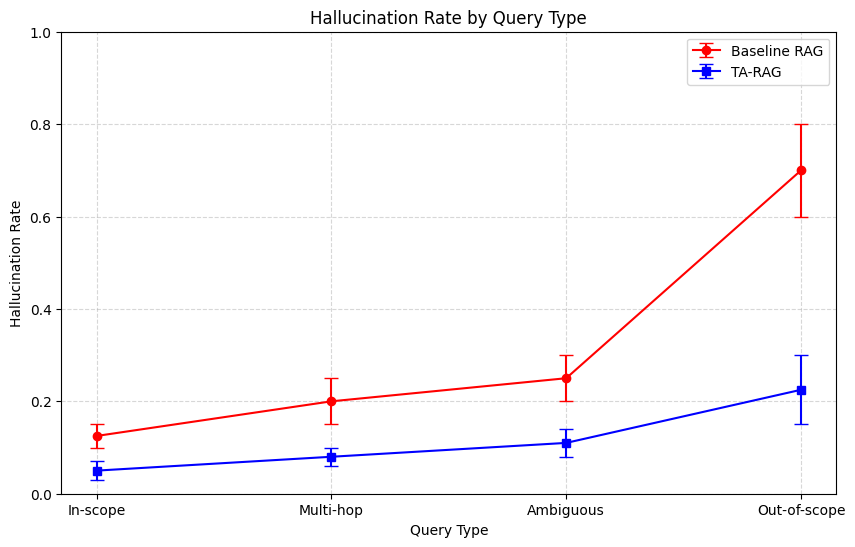

In [1]:
import matplotlib.pyplot as plt
import numpy as np

# Query types
query_types = ['In-scope', 'Multi-hop', 'Ambiguous', 'Out-of-scope']

# Mid-point approximation for ranges
baseline_hr = [0.125, 0.20, 0.25, 0.70]   # mid-point of baseline ranges
ta_rag_hr   = [0.05, 0.08, 0.11, 0.225]   # mid-point of TA-RAG ranges

# Optional: error bars from min/max ranges
baseline_err = [[0.125-0.10, 0.20-0.15, 0.25-0.20, 0.70-0.60],  # lower
                [0.15-0.125, 0.25-0.20, 0.30-0.25, 0.80-0.70]]  # upper
ta_rag_err = [[0.05-0.03, 0.08-0.06, 0.11-0.08, 0.225-0.15],
              [0.07-0.05, 0.10-0.08, 0.14-0.11, 0.30-0.225]]

# Convert error bars to symmetric format for matplotlib
baseline_yerr = np.array([baseline_err[0], baseline_err[1]])
ta_rag_yerr = np.array([ta_rag_err[0], ta_rag_err[1]])

# Plot
plt.figure(figsize=(10,6))
plt.errorbar(query_types, baseline_hr, yerr=baseline_yerr, fmt='-o', label='Baseline RAG', capsize=5, color='red')
plt.errorbar(query_types, ta_rag_hr, yerr=ta_rag_yerr, fmt='-s', label='TA-RAG', capsize=5, color='blue')

plt.title('Hallucination Rate by Query Type')
plt.ylabel('Hallucination Rate')
plt.xlabel('Query Type')
plt.ylim(0, 1)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend()
plt.show()


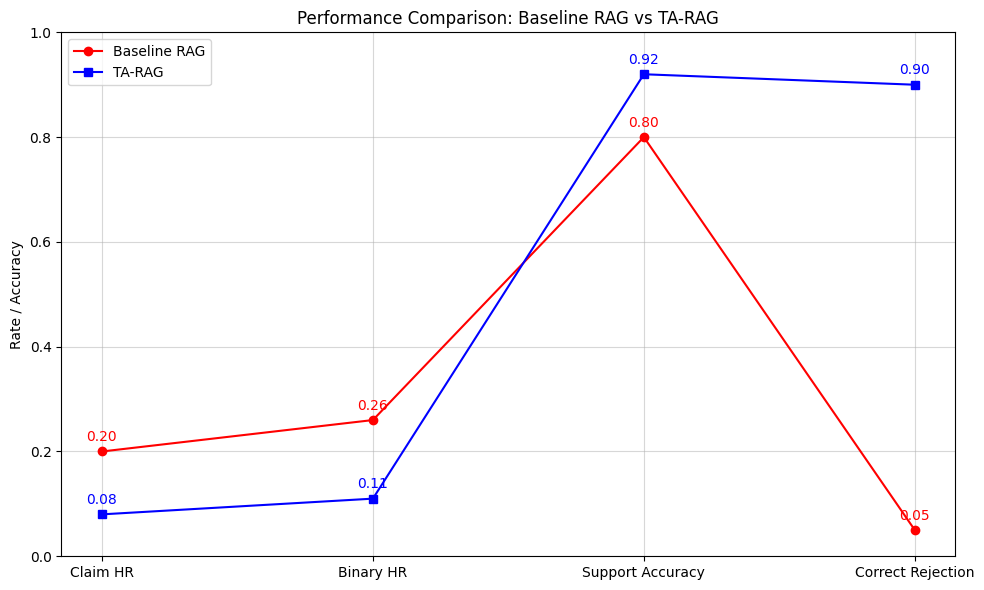

In [4]:
import matplotlib.pyplot as plt
import numpy as np

# Metrics
metrics = ["Claim HR", "Binary HR", "Support Accuracy", "Correct Rejection"]
baseline_values = [0.20, 0.26, 0.80, 0.05]
ta_rag_values = [0.08, 0.11, 0.92, 0.90]

x = np.arange(len(metrics))

plt.figure(figsize=(10,6))

# Plot lines
plt.plot(x, baseline_values, marker='o', linestyle='-', color='red', label='Baseline RAG')
plt.plot(x, ta_rag_values, marker='s', linestyle='-', color='blue', label='TA-RAG')

# X-axis labels
plt.xticks(x, metrics)
plt.ylim(0, 1)
plt.ylabel('Rate / Accuracy')
plt.title('Performance Comparison: Baseline RAG vs TA-RAG')
plt.grid(True, linestyle='-', alpha=0.5)
plt.legend()

# Add values on each point
for i, v in enumerate(baseline_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10, color='red')
for i, v in enumerate(ta_rag_values):
    plt.text(i, v + 0.02, f"{v:.2f}", ha='center', fontsize=10, color='blue')

plt.tight_layout()
plt.show()
